# 4. Simulación de las variables meteorológicas de la celda 01.
## Preparación del entorno y rutas

In [1]:
from carga_de_datos import *
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 4.1. Simulación con las distribuciones elegidas en el punto 2.2
En este subapartado se realiza la simulación de las variables meteorológicas de la celda 01 con las distribuciones ajustadas en el apartado 2.2, con el fin de comparar los datos simulados frente a los datos reales y analizar cómo mejora la aproximación al aumentar el tamaño muestral.
### Pregunta
A partir de las distribuciones elegidas en el punto 2.2 para la irradiación, la temperatura y la precipitación de la celda 01, y de forma independiente, se generan cuatro muestras de números pseudoaleatorios de tamaño n1 = 10, n2 = 100, n3 = 1000 y n4 = 10000 para cada variable.
Para cada variable y cada tamaño muestral, se representa en una misma gráfica la distribución de la muestra simulada junto con la de los datos reales, y se discute qué se observa conforme aumenta el tamaño de la muestra.

In [2]:
# Función auxiliar para no repetir el mismo bloque de código en cada variable.
def plot_histogramas(x_real, VA, x1, x2, x3, x4, nombre_variable, nombre_imagen):
    fig = plt.figure(figsize=(14, 10))

    muestras = [x1, x2, x3, x4]
    tamaños = [10, 100, 1000, 10000]
    unidades = {
        'Temperatura': 'Temperatura (°C)',
        'Irradiación': 'Irradiación (J/m²)',
        'Precipitación': 'Precipitación (m)',
    }
    etiqueta_eje = unidades.get(nombre_variable, nombre_variable)

    for i in range(4):
        plt.subplot(2, 2, i + 1)

        x_sim = muestras[i]
        n = tamaños[i]

        xmin = min(np.min(x_real), np.min(x_sim))
        xmax = max(np.max(x_real), np.max(x_sim))
        margen = 0.05 * (xmax - xmin) if xmax > xmin else 1
        xs = np.linspace(xmin - margen, xmax + margen, 1000)

        plt.hist(x_real, bins=30, density=True, alpha=0.6,
                 label='Datos reales', color='steelblue',
                 edgecolor='black', linewidth=0.5)

        plt.hist(x_sim, bins=30, density=True, alpha=0.5,
                 label=f'Simulación (n={n})', color='coral',
                 edgecolor='black', linewidth=0.5)

        plt.plot(xs, VA.pdf(xs), 'g-', linewidth=2.5,
                 label='Función de densidad teórica')

        plt.title(f'n = {n}', fontsize=11, fontweight='bold')
        plt.xlabel(etiqueta_eje)
        plt.ylabel('Densidad')
        plt.legend(fontsize=9)
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'{nombre_imagen}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Se fijan aquí los tamaños muestrales porque se usan en todos los apartados.
n1 = 10
n2 = 100
n3 = 1000
n4 = 10000

Parámetros temperatura (triangular): (np.float64(0.2852643846843769), np.float64(1.7239338685154788), np.float64(36.831829557286525))


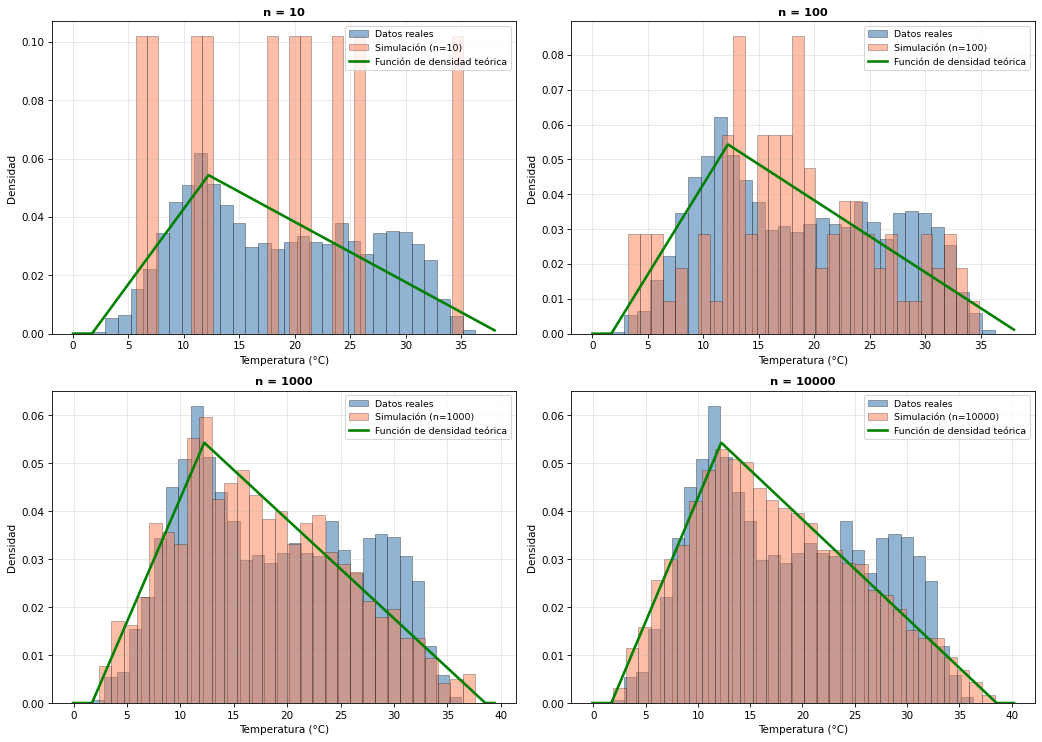

In [3]:
# Temperatura

semilla = 99999
np.random.seed(semilla)

x_real = df_orig_temp["TEMP_CELDA01"].dropna().values

# Tomamos la triangular del apartado 2.2.
params = stats.triang.fit(x_real)

c = params[0]
loc = params[1]
scale = params[2]
VA = stats.triang(c=c, loc=loc, scale=scale)

print("Parámetros temperatura (triangular):", params)

x1 = VA.rvs(size=n1)
x2 = VA.rvs(size=n2)
x3 = VA.rvs(size=n3)
x4 = VA.rvs(size=n4)

plot_histogramas(
    x_real,
    VA,
    x1,
    x2,
    x3,
    x4,
    "Temperatura",
    "Gráfico 4.1： Distribución de las simulaciones de la temperatura en la celda 01 por tamaños muestrales",
)

Parámetros irradiación (triangular): (np.float64(0.9640841834647736), np.float64(-110483.64769757228), np.float64(1420888.0004384872))


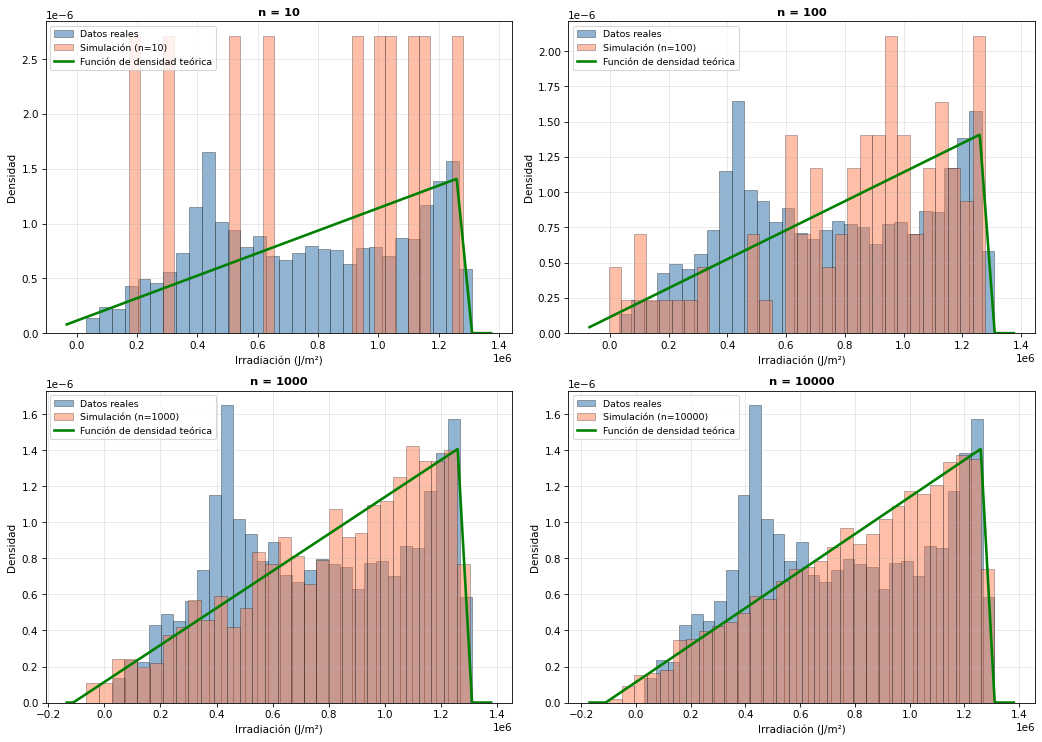

In [4]:
# Irradiación

semilla = 99999
np.random.seed(semilla)

x_real = df_orig_irrad["IRRAD_CELDA01"].dropna().values

# Tomamos la triangular del apartado 2.2.
params = stats.triang.fit(x_real)

c = params[0]
loc = params[1]
scale = params[2]
VA = stats.triang(c=c, loc=loc, scale=scale)

print("Parámetros irradiación (triangular):", params)

x1 = VA.rvs(size=n1)
x2 = VA.rvs(size=n2)
x3 = VA.rvs(size=n3)
x4 = VA.rvs(size=n4)

plot_histogramas(
    x_real,
    VA,
    x1,
    x2,
    x3,
    x4,
    "Irradiación",
    "Gráfico 4.2： Distribución de las simulaciones de la irradiación en la celda 01 por tamaños muestrales",
)

C:\Users\anton\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_continuous_distns.py:806: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
C:\Users\anton\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_continuous_distns.py:811: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


Parámetros precipitación (beta): (np.float64(0.215554992236624), np.float64(244.44240356690347), np.float64(-3.651452321621044e-30), np.float64(0.005676448510223973))


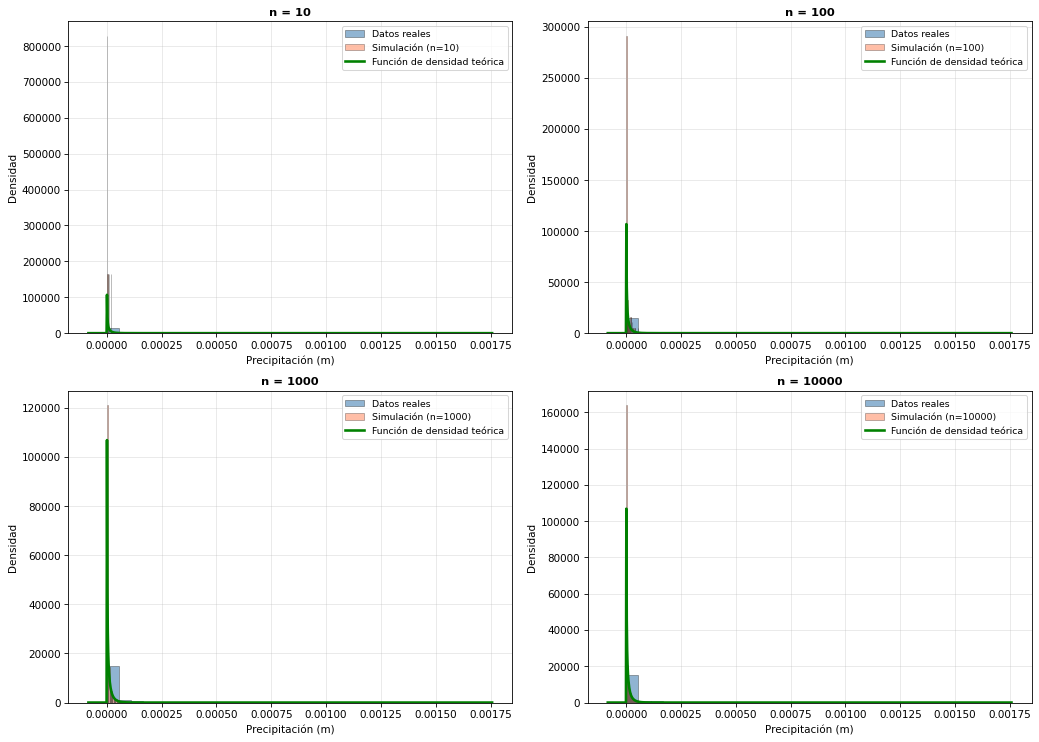

In [5]:
# Precipitación

semilla = 99999
np.random.seed(semilla)

x_real = df_orig_precip["PRECIP_CELDA01"].dropna().values

# Tomamos la Beta del apartado 2.2.
params = stats.beta.fit(x_real)

# Creamos la variable aleatoria "VA" que sigue una beta.
a = params[0]
b = params[1]
loc = params[2]
scale = params[3]
VA = stats.beta(a, b, loc=loc, scale=scale)

print("Parámetros precipitación (beta):", params)

x1 = VA.rvs(size=n1)
x2 = VA.rvs(size=n2)
x3 = VA.rvs(size=n3)
x4 = VA.rvs(size=n4)

plot_histogramas(
    x_real,
    VA,
    x1,
    x2,
    x3,
    x4,
    "Precipitación",
    "Gráfico 4.3： Distribución de las simulaciones de la precipitación en la celda 01 por tamaños muestrales",
)

In [6]:
print("En este apartado se analizan las simulaciones de las variables temperatura, irradiación y precipitación en la celda 01, utilizando las distribuciones ajustadas previamente en el apartado 2.2.\n"
      "Para cada variable, se generan muestras pseudoaleatorias de distintos tamaños (n = 10, 100, 1000 y 10000) y se compara, en cada caso, la distribución simulada con los datos reales y con la función de densidad teórica.\n"
      "De forma general, se observa un comportamiento consistente en las tres variables en función del tamaño muestral.\n"
      "Para tamaños pequeños, como n = 10, las distribuciones simuladas presentan una elevada variabilidad y una forma irregular, lo que dificulta su aproximación tanto a los datos reales como a la densidad teórica.\n"
      "Al aumentar el tamaño de la muestra, como en n = 100 y n = 1000, la distribución empírica de los datos simulados se vuelve progresivamente más estable, reduciendo las fluctuaciones aleatorias y aproximándose mejor a la forma general de los datos observados.\n"
      "Para tamaños grandes, como n = 10000, la distribución simulada converge claramente hacia la distribución teórica ajustada, mostrando una alta estabilidad y una buena alineación con la forma global de los datos reales.\n"
      "No obstante, se aprecia que incluso en estos casos existen ciertas diferencias entre la simulación y los datos observados, lo que muestra que el ajuste de las distribuciones elegidas, aunque sean adecuadas, no captura completamente la complejidad de las variables reales.\n"
      "En conclusión, el análisis muestra que el aumento del tamaño muestral mejora notablemente la aproximación de las distribuciones simuladas a la distribución teórica, reduciendo la variabilidad y aumentando la estabilidad de los resultados.\n"
      "Este comportamiento es coherente con la Ley de los Grandes Números, que establece que, a medida que el tamaño de la muestra aumenta, las distribuciones empíricas tienden a aproximarse a la distribución real de la población.")

En este apartado se analizan las simulaciones de las variables temperatura, irradiación y precipitación en la celda 01, utilizando las distribuciones ajustadas previamente en el apartado 2.2.
Para cada variable, se generan muestras pseudoaleatorias de distintos tamaños (n = 10, 100, 1000 y 10000) y se compara, en cada caso, la distribución simulada con los datos reales y con la función de densidad teórica.
De forma general, se observa un comportamiento consistente en las tres variables en función del tamaño muestral.
Para tamaños pequeños, como n = 10, las distribuciones simuladas presentan una elevada variabilidad y una forma irregular, lo que dificulta su aproximación tanto a los datos reales como a la densidad teórica.
Al aumentar el tamaño de la muestra, como en n = 100 y n = 1000, la distribución empírica de los datos simulados se vuelve progresivamente más estable, reduciendo las fluctuaciones aleatorias y aproximándose mejor a la forma general de los datos observados.
Para tamañ

### Respuesta

El comportamiento de las simulaciones es coherente con lo esperado al aumentar el tamaño muestral. Con n = 10, las muestras simuladas presentan una forma irregular y una alta variabilidad, por lo que su aproximación a los datos reales y a la distribución teórica es limitada. Con n = 100, la distribución comienza a estabilizarse y ya refleja mejor la forma general de la población.

A partir de n = 1000, la similitud con la distribución teórica se vuelve mucho más clara, y con n = 10000 la convergencia es muy evidente: la forma del histograma simulado se alinea de manera muy próxima con la de los datos reales y con la función de densidad ajustada.

En conjunto, el apartado muestra que el aumento del tamaño de la muestra reduce la variabilidad de la simulación y mejora la representación de la distribución poblacional. Este resultado es coherente con la Ley de los Grandes Números, que indica que, al crecer n, la distribución empírica tiende a estabilizarse y a aproximarse a la distribución teórica de referencia.